In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import wandb
from sklearn.metrics import f1_score
from tqdm import tqdm

In [2]:
# .npz laden
train = np.load("../Model_data/train_split1_100WS.npz")
test  = np.load("../Model_data/test_split1_100WS.npz")

X_train, y_train = train["X"], train["y"]
X_test,  y_test  = test["X"],  test["y"]

# X_train hat die Form (Anzahl Windows, Zeitschritte pro Window, Anzahl Features)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(21167, 100, 13)
(21167,)
(3969, 100, 13)
(3969,)


In [3]:
# PyTorch braucht numerische Klassen
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# NumPy zu PyTorch Tensoren und umformen zu (N, 13, 100) (Chanels in der Mitte) für CNN, nicht bei LSTM
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).permute(0, 2, 1)

y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long)

# Datasets erstellen als Tensoren
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

# GPU falls verfügbar
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\jessi\_netrc.
wandb: Currently logged in as: jessischmid01 (CDL1_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 1D-CNN Aufbau

In [48]:
class CNN1D(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.net(x))
    

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),  # Dropout direkt nach Aktivierung
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class CNN1D_Residual(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.3):
        super().__init__()
        
        # Stem: breiterer Kernel für längere Zeitabhängigkeiten
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        
        # Block 1: 64 Kanäle
        self.res1a = ResidualBlock(64, dropout)
        self.res1b = ResidualBlock(64, dropout)
        
        # Downsampling 64 -> 128
        self.down1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        
        # Block 2: 128 Kanäle
        self.res2a = ResidualBlock(128, dropout)
        self.res2b = ResidualBlock(128, dropout)
        
        # Downsampling 128 -> 256
        self.down2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )
        
        # Block 3: 256 Kanäle 
        self.res3 = ResidualBlock(256, dropout)
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Grösserer Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res1a(x)
        x = self.res1b(x)
        x = self.down1(x)
        x = self.res2a(x)
        x = self.res2b(x)
        x = self.down2(x)
        x = self.res3(x)
        x = self.pool(x)
        return self.classifier(x)

## Namensgebungen

Die Bezeichnungen der Durchläufe haben sich im Laufe der Zeit geändert: 1D-CNN_v3... Die verschiedenen Versionen sind:

- Version 1 war ohne Datenaugmentierung und andere Verfeinerungen
- Version 2 nutzt Datenaugmentierung und ein Learningrate scheduler eingebaut, verwendet aber noch die alte Datenaufteilung
- Version 3 nutzt die neue Aufteilung in Trainings- und Testdaten, bei der wir die Daten nach Benutzern getrennt haben
- Version 4 hat label_smoothing=0.1 im criterion, mehr Daten Agumentation und hat eine eingebauten ResidualBlock (Skipconnection) wegen Vanashing Gradient
- Version 5 neuer Split mit besserer Aufteilung der Personen auf die Klassen ohne Überschneidungen
- Version 6 Tieferes Netzwerk und Augmentation durch eine weitere ergänzt


In [57]:
def evaluate(model, loader, criterion, device):
    """
    Gibt loss, accuracy und f1-macro für einen DataLoader zurück.
    Wird für Train- und Validation-Set verwendet.
    """
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            total_loss += criterion(preds, y_batch).item()
            correct += (preds.argmax(1) == y_batch).sum().item()
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    n = len(loader.dataset)
    avg_loss = total_loss / len(loader)
    acc = correct / n
    f1 = f1_score(all_labels, all_preds, average="macro")

    return {"loss": avg_loss, "acc": acc, "f1": f1}

def augment(X_batch):
        # Gaussian Noise
    X_batch = X_batch + torch.randn_like(X_batch) * 0.01

    # Amplitude Scaling: pro Sample ein zufälliger Faktor zwischen 0.9 und 1.1
    scale = 0.9 + torch.rand(X_batch.size(0), 1, 1, device=X_batch.device) * 0.2
    X_batch = X_batch * scale

    # Channel Dropout: einzelne Sensorkanäle auf 0 setzen
    B, C, T = X_batch.shape
    if torch.rand(1).item() < 0.3:
        ch = torch.randint(0, C, (1,)).item()
        X_batch[:, ch, :] = 0

    # Time Warping: zufälliger zeitlicher Shift
    shift = torch.randint(-10, 10, (1,)).item()
    X_batch = torch.roll(X_batch, shifts=shift, dims=2)

    # Magnitude Warping: per-Kanal leichte Skalierung
    mag = 0.95 + torch.rand(B, C, 1, device=X_batch.device) * 0.1
    X_batch = X_batch * mag

    # NEU: Stärkerer Channel Dropout (ganze Sensor-Gruppen)
    B, C, T = X_batch.shape
    n_drop = torch.randint(0, 3, (1,)).item()  # 0-2 Kanäle droppen
    for _ in range(n_drop):
        ch = torch.randint(0, C, (1,)).item()
        X_batch[:, ch, :] = 0
    return X_batch

def augment_lstm(X_batch):
    # (N, T, C) → (N, C, T) für bestehende augment-Funktion
    X_batch = X_batch.permute(0, 2, 1)
    X_batch = augment(X_batch)
    X_batch = X_batch.permute(0, 2, 1)   # zurück zu (N, T, C)

    # Ab hier ist X_batch wieder (N, T, C)
    B, T, C = X_batch.shape

    # Cutout: zufälligen Zeitabschnitt auf 0 setzen
    if torch.rand(1).item() < 0.3:
        cut_len = torch.randint(5, 20, (1,)).item()
        start = torch.randint(0, T - cut_len, (1,)).item()
        X_batch[:, start:start + cut_len, :] = 0

    return X_batch

def train(config, train_ds, test_ds, device, project="CDL1", model_class=CNN1D_Residual):
    """
    Trainiert ein CNN1D Modell mit den gegebenen Hyperparametern.

    Args:
        config: Dictionary mit allen Hyperparametern
        train_loader: DataLoader für Trainingsdaten
        test_loader: DataLoader für Validierungsdaten
        device: torch.device (cuda / cpu)
        project: W&B Projektname

    Returns:
        model: Trainiertes Modell (bestes nach val/f1)
        history: Dictionary mit Metriken pro Epoch
    """
    # Wandb Run initialisieren
    fold_suffix = f"_Fold{config['fold']}" if "fold" in config else ""
    run = wandb.init(
        project=project,
        entity="CDL1_team",
        config=config,
        name=f"{config["model"]}_lr{config['lr']}_bs{config['batch_size']}_do{config['dropout']}{fold_suffix}"
    )
    cfg = wandb.config

    # DataLoader wird jetzt mit der config Batch Size erstellt
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False)

    if model_class in (LSTMClassifier, BiLSTMClassifier, CNNLSTMClassifier, LSTMAttentionClassifier):
        model = model_class(
            n_features=cfg.n_features,
            n_classes=cfg.n_classes,
            hidden_size=cfg.hidden_size,
            num_layers=cfg.num_layers,
            dropout=cfg.dropout
        ).to(device)
    else:
        # Modell, Optimizer, Loss festlegen, Adam passt die Lernrate während dem Training an
        model = model_class(cfg.n_features, cfg.n_classes, dropout=cfg.dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    is_lstm = model_class in (LSTMClassifier, BiLSTMClassifier, LSTMAttentionClassifier)

    if is_lstm:
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=cfg.lr,
            epochs=cfg.epochs,
            steps_per_epoch=len(train_loader)
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    wandb.watch(model, log="all", log_freq=50)

    # Variablen um beste F1 Scores und die dazugehörigen Gewichte zu speichern
    history = {"train": [], "val": []}
    best_f1 = 0.0
    best_state = None

    # hinzufügen von tqdm, damit man den Fortschritt sieht
    epoch_bar = tqdm(range(cfg.epochs), desc="Training", unit="epoch")

    for epoch in epoch_bar:

        model.train()
        train_loss, train_correct = 0, 0
        all_preds, all_labels = [], []

        batch_bar = tqdm(train_loader, desc=f"  Epoch {epoch+1:02d}", leave=False, unit="batch")

        for X_batch, y_batch in batch_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # verwendung der richtigen Augmentation
            is_lstm = model_class in (LSTMClassifier, BiLSTMClassifier, LSTMAttentionClassifier)
            X_batch = augment_lstm(X_batch) if is_lstm else augment(X_batch)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)    # clipping wegen LSTM
            optimizer.step()

            train_loss += loss.item()
            train_correct += (preds.argmax(1) == y_batch).sum().item()
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
            # Aktuellen Loss direkt im Batch-Balken anzeigen
            batch_bar.set_postfix(loss=f"{loss.item():.3f}")

            if is_lstm:
                scheduler.step()
        
        if not is_lstm:
            scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        train_metrics = {
            "loss": train_loss / len(train_loader),
            "acc": train_correct / len(train_loader.dataset),
            "f1": f1_score(all_labels, all_preds, average="macro"),
        }

        # Validation
        val_metrics = evaluate(model, test_loader, criterion, device)

        # Bestes Modell speichern
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = model.state_dict().copy()

        # History & W&B loggen 
        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_metrics["loss"],
            "train/acc": train_metrics["acc"],
            "train/f1": train_metrics["f1"],
            "val/loss": val_metrics["loss"],
            "val/acc": val_metrics["acc"],
            "val/f1": val_metrics["f1"],
            "train/lr": current_lr,
        })

        # Epoch-Balken mit finalen Metriken aktualisieren
        epoch_bar.set_postfix({
            "train_f1": f"{train_metrics['f1']:.3f}",
            "val_f1": f"{val_metrics['f1']:.3f}",
            "val_acc": f"{val_metrics['acc']:.3f}",
        })

    # Bestes Modell laden und zurückgeben
    model.load_state_dict(best_state)
    wandb.unwatch(model)
    wandb.finish()

    return model, history

In [59]:
# windowing_size und step_size sind im sliding window der Datenbearbeitung vorhanden und dienen nur der Dokumentation
config = {
    "model": "1D-CNN_v6",
    "window_size": 100,
    "step_size": 50,
    "batch_size": 32,
    "lr": 0.001,
    "epochs": 20,
    "n_features": 13,
    "n_classes": len(le.classes_),
    "dropout": 0.5
}

model, history = train(
    config = config,
    train_ds = train_ds,
    test_ds = test_ds,
    device = device,
    project = "CDL1",
    model_class= CNN1D_Residual
)

Training: 100%|██████████| 20/20 [04:54<00:00, 14.71s/epoch, train_f1=0.941, val_f1=0.755, val_acc=0.800]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▇▇▇▇▇▇▇▇████████
train/f1,▁▅▆▇▇▇▇▇▇▇██████████
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▃▆▇▄▂▃▄▄█▅▆▅▇▁▆█▅▇▃▆
val/f1,▁▅▇▄▅▄▅▆█▇▆▆▇▃▇▇▆▆▅▆
val/loss,▃▂▁▅▆▅▄▄▂▄▄▄▃█▃▂▅▂▅▃
epoch,20
train/acc,0.9641
train/f1,0.94052


# Erwartungen Gridsearch

Batchsize beeinflusst die Varianz der Gradienten, somit sind die Updates ungenauer, wenn wir eine kleine Batchsize haben. Dafür kann man mit tiefen Batchsizes eher einem lokalen Minima entweichen und besser generalisieren. Um Stabilität im Training zu haben, muss dafür bei kleiner Batchsize die Lernrate auch klein sein. Für grössere Batchsizes, können dafür grössere Lernraten verwendet werden. 

Dropout ist eine Regularisierungsmethode, bei dem im Fully connected Layer eine gewisse Prozentzahl an Neuronen zufällig ausgeschalten werden. So sollte das Overfitting reduziert werden. 

Folglich sollten folgende Kombinationen gut funktionieren:

lr: 0.01 + bs: 128 + do: 0.4
lr: 0.001 + bs: 64 + do: 0.4
lr: 0.0001 + bs: 32 + do: 0.4

In [31]:
import itertools

In [ ]:
# Grid 1 definieren
param_grid = {
    "lr": [0.005, 0.001, 0.0005],
    "batch_size": [32, 64],
    "dropout": [0.3, 0.4, 0.5],
}

# Alle Kombinationen erzeugen
keys, values = zip(*param_grid.items())
combinations = list(itertools.product(*values))
print(f"Gesamt: {len(combinations)} Kombinationen")

# Ergebnisse sammeln
results = []

for i, combo in enumerate(combinations, 1):
    params = dict(zip(keys, combo))
    print(f"\n[{i}/{len(combinations)}] {params}")

    cfg = {
        "model": "1D-CNN-Res_v6",
        "window_size": 100,
        "step_size": 50,
        "epochs": 20,
        "n_features": 13,
        "n_classes": len(le.classes_),
        **params,  # lr, batch_size, dropout werden überschrieben
    }

    model, history = train(
        config = cfg,
        train_ds = train_ds,
        test_ds = test_ds,
        device = device,
        project = "CDL1",
        model_class= CNN1D
    )

    # Bestes val/f1 aus der History holen
    best_val_f1 = max(e["f1"]  for e in history["val"])
    best_val_acc = max(e["acc"] for e in history["val"])

    results.append({
        **params,
        "best_val_f1": best_val_f1,
        "best_val_acc": best_val_acc,
        "model": model,
        "history": history,
    })

    print(f" best val/f1: {best_val_f1:.4f}  |  best val/acc: {best_val_acc:.4f}")

# Nach F1 sortieren und Top-3 ausgeben
results.sort(key=lambda x: x["best_val_f1"], reverse=True)


Gesamt: 18 Kombinationen

[1/18] {'lr': 0.01, 'batch_size': 32, 'dropout': 0.2}


Training: 100%|██████████| 20/20 [01:58<00:00,  5.91s/epoch, train_f1=0.961, val_f1=0.722, val_acc=0.786]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▆▇▇▇▇▇▇▇▇███████
train/f1,▁▅▆▆▇▇▇▇▇▇▇▇▇███████
train/loss,█▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▂▁▄██▅█▆▇▅█▄▅▄▇▅▅▄▆▅
val/f1,▁▂▅██▆█▇▇▆▇▆▆▆▇▆▅▅▆▆
val/loss,█▇▄▁▁▅▂▃▂▄▂▆▄▅▃▄▄▅▃▄
epoch,20
train/acc,0.97454
train/f1,0.96128


 best val/f1: 0.7655  |  best val/acc: 0.8456

[2/18] {'lr': 0.01, 'batch_size': 32, 'dropout': 0.3}


Training: 100%|██████████| 20/20 [02:31<00:00,  7.58s/epoch, train_f1=0.960, val_f1=0.735, val_acc=0.791]


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▆▇▇▇▇▇█████████████
train/f1,▁▅▆▇▇▇▇█████████████
train/loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▁▅▆█▇▇███▅▅▇▇▇▆▅▇▇▆▆
val/f1,▁▅▇▇▇████▇▇██▇▇▇██▇▇
val/loss,█▃▅▂▄▂▁▂▁▅▄▂▂▂▃▄▂▂▄▃
epoch,20
train/acc,0.96532
train/f1,0.94456


 best val/f1: 0.7185  |  best val/acc: 0.7773

[18/18] {'lr': 0.0001, 'batch_size': 64, 'dropout': 0.5}


Training: 100%|██████████| 20/20 [01:12<00:00,  3.64s/epoch, train_f1=0.943, val_f1=0.695, val_acc=0.752]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▇▇▇▇█████████████
train/f1,▁▅▆▇▇▇▇█████████████
train/loss,█▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▁▄▅▅▆▆█▇█▇▇▇▆▇▇▇▆▇▇▆
val/f1,▁▅▆▆▆▇█▇█▇██▇▇██▇▇▇▇
val/loss,██▄▄▃▃▁▃▁▄▂▂▃▃▂▂▄▃▃▃
epoch,20
train/acc,0.96296
train/f1,0.94257


 best val/f1: 0.7238  |  best val/acc: 0.7826


In [ ]:
print("\n" + "="*60)
print("TOP 3 KONFIGURATIONEN")
print("="*60)
for rank, r in enumerate(results[:3], 1):
    print(f"\n#{rank}  val/f1={r['best_val_f1']:.4f}  acc={r['best_val_acc']:.4f}")
    print(f"     lr={r['lr']}  batch_size={r['batch_size']}  dropout={r['dropout']}")

# Bestes Modell direkt verfügbar
best = results[0]
best_model = best["model"]
print(f"\nBestes Modell geladen: lr={best['lr']}, bs={best['batch_size']}, do={best['dropout']}")

## Ergebnisse Gridsearch

Die Ergebnisse von den ersten Versüchen mit der falschen Datenaufteilung sind nur auf WanDB zu finden. Die Ergebnisse mit dem Model CNN1D sind unterhalb zu finden. 

In [9]:
from IPython.display import IFrame

In [11]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/kmdd9ktm",
    width=1100, height=600
)

In [10]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/lkbb7jci",
    width=1100, height=600
)

# Cross-Validation

Als nächstes wird die Cross-Validation 5-Fold auf das Model mit der besten Parameterkombination angewendet. So sieht man auch wie gross die Varianz zwischen den Vorhersagen ist. 

In [42]:
from sklearn.model_selection import StratifiedKFold

In [43]:

best_config = {
    "model":       "1D-CNN",
    "window_size": 100,
    "step_size":   50,
    "epochs":      30,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "lr":          0.001,
    "batch_size":  32,
    "dropout":     0.2,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_t, y_train_t), 1):
    print(f"\n{'='*40}\nFold {fold}/5\n{'='*40}")

    fold_train_ds = TensorDataset(X_train_t[train_idx], y_train_t[train_idx])
    fold_val_ds   = TensorDataset(X_train_t[val_idx],   y_train_t[val_idx])

    _, history = train(
        config = {**best_config, "fold": fold},
        train_ds = fold_train_ds,
        test_ds = fold_val_ds,
        device = device,
        project = "CDL1",
        model_class= CNN1D
    )

    best_f1  = max(e["f1"]  for e in history["val"])
    best_acc = max(e["acc"] for e in history["val"])
    fold_results.append({"fold": fold, "f1": best_f1, "acc": best_acc})
    print(f"Fold {fold} --> F1: {best_f1:.4f} | Acc: {best_acc:.4f}")

print(f"\n{'='*40}\nFinales Modell (alle Trainingsdaten)\n{'='*40}")

final_model, final_history = train(
    config   = {**best_config, "fold": "final"},
    train_ds = TensorDataset(X_train_t, y_train_t),
    test_ds  = TensorDataset(X_test_t,  y_test_t),
    device   = device,
    project  = "CDL1",
)

final_f1  = max(e["f1"]  for e in final_history["val"])
final_acc = max(e["acc"] for e in final_history["val"])

f1s  = [r["f1"]  for r in fold_results]
accs = [r["acc"] for r in fold_results]

print("\n" + "="*40)
print("ERGEBNIS")
print("="*40)
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f} | Acc={r['acc']:.4f}")
print(f"{'─'*40}")
print(f"  CV Mean:  F1={np.mean(f1s):.4f} | Acc={np.mean(accs):.4f}")
print(f"  CV Std:   F1={np.std(f1s):.4f}  | Acc={np.std(accs):.4f}")
print(f"{'─'*40}")
print(f"  Final:    F1={final_f1:.4f} | Acc={final_acc:.4f}  ← Testset")


Fold 1/5


Training: 100%|██████████| 30/30 [03:08<00:00,  6.28s/epoch, train_f1=0.974, val_f1=0.976, val_acc=0.986]


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train/f1,▁▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train/loss,█▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▁▁▂▃▂▃▃▂▃▄▄▁▄▆▅▄▆▇▆▇█▇▇███▇█▇▇
val/f1,▁▂▃▃▃▃▃▃▃▄▅▁▄▆▆▄▆▇▆▇██▇█████▇█
val/loss,██▆▅▅▄▄▅▄▄▄▅▃▂▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,30
train/acc,0.98211
train/f1,0.97449


Fold 1 --> F1: 0.9798 | Acc: 0.9882

Fold 2/5


Training: 100%|██████████| 30/30 [03:08<00:00,  6.27s/epoch, train_f1=0.975, val_f1=0.980, val_acc=0.988]


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train/f1,▁▅▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇████████████
train/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▁▃▅▅▅▅▅▅▅▆▆▅▆▇▆▇█▇▇███████████
val/f1,▁▂▅▄▅▅▅▅▅▅▅▅▆▇▅▇▇▇▇▇██████████
val/loss,█▆▄▄▄▄▃▄▄▃▃▃▂▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,30
train/acc,0.98352
train/f1,0.9749


Fold 5 --> F1: 0.9867 | Acc: 0.9903

Finales Modell (alle Trainingsdaten)


Training: 100%|██████████| 30/30 [04:54<00:00,  9.81s/epoch, train_f1=0.972, val_f1=0.699, val_acc=0.738]


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
train/f1,▁▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▇▅▁▁█▃▅▆▃█▁▆▇▆▁▆▅▂▅▅█▅▄▄▅▄▅▄▄▄
val/f1,▅▅▂▃▇▃▅▆▄█▃▅▇▄▁▆▆▃▅▅█▄▄▄▅▄▅▄▄▄
val/loss,▂▄▆▆▁▆▅▄▅▂▇▃▂▃█▃▄▆▄▄▁▄▄▄▄▅▄▅▅▅
epoch,30
train/acc,0.98167
train/f1,0.97232



ERGEBNIS
  Fold 1: F1=0.9798 | Acc=0.9882
  Fold 2: F1=0.9823 | Acc=0.9891
  Fold 3: F1=0.9794 | Acc=0.9851
  Fold 4: F1=0.9864 | Acc=0.9903
  Fold 5: F1=0.9867 | Acc=0.9903
────────────────────────────────────────
  CV Mean:  F1=0.9829 | Acc=0.9886
  CV Std:   F1=0.0031  | Acc=0.0019
────────────────────────────────────────
  Final:    F1=0.7639 | Acc=0.8226  ← Testset


In [ ]:
print("\n" + "="*40)
print("ERGEBNIS")
print("="*40)
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f} | Acc={r['acc']:.4f}")
print(f"{'─'*40}")
print(f"  CV Mean:  F1={np.mean(f1s):.4f} | Acc={np.mean(accs):.4f}")
print(f"  CV Std:   F1={np.std(f1s):.4f}  | Acc={np.std(accs):.4f}")
print(f"{'─'*40}")
print(f"  Final:    F1={final_f1:.4f} | Acc={final_acc:.4f}  (auf Testset)")

## Cross Validation Ergebnisse

Die Vorherigen Ergebnisse sind auf WanDB einzeln zu finden. 

In [13]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/sso3cy0j",
    width=1100, height=600
)

## Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

def plot_confusion_matrix(model, loader, device, class_names, save_path= None, name= None):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Gespeichert: {save_path}")

    plt.show()

In [ ]:
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

plot_confusion_matrix(
    model = final_model,
    loader = test_loader,
    device = device,
    class_names = le.classes_,   # gibt die originalen Label-Namen wie "Zug" und "Auto"
    name = "Confusion Matrix - CNN1D Residual V5",
    save_path= "Confusion_Matrix/CNN1D_Residual_lr0.01_bs32_do0.3.png"
)

# LSTM Ansatz

Als zweites wird noch versucht mit einem LSTM Ansatz bessere Ergebnisse zu erlangen. 
Da das LSTM bessere Ergebnisse erzielen konnte, wie das Bidirektionale LSTM wurde dies noch versucht mit Self Attention zu verbessern. 

In [8]:
# Für LSTM ist kein permute nötig (N, Zeit, Features)
X_train_lstm = torch.tensor(X_train, dtype=torch.float32)  # (N, 100, 13)
X_test_lstm  = torch.tensor(X_test,  dtype=torch.float32)

train_ds_lstm = TensorDataset(X_train_lstm, y_train_t)
test_ds_lstm  = TensorDataset(X_test_lstm,  y_test_t)

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128, 
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,     
            hidden_size=hidden_size,    # Anzahl LSTM-Units pro Layer
            num_layers=num_layers,      # Gestapelte LSTM-Schichten
            batch_first=True,           # Erwartet (N, Zeit, Features)
            dropout=dropout if num_layers > 1 else 0,  # nur zwischen Layers
            bidirectional=False
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (N, 100, 13)
        out, (h_n, c_n) = self.lstm(x)
        # Nur den letzten Zeitschritt verwenden
        last = out[:, -1, :]            # (N, hidden_size)
        return self.classifier(last)

# Bidirektionaler Ansatz
class BiLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True           # vorwärts + rückwärts
        )
        # bidirectional verdoppelt die Output-Grösse
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]            # (N, hidden_size * 2)
        return self.classifier(last)
    
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out: (N, T, hidden_size)
        weights = torch.softmax(self.attn(lstm_out), dim=1)  # (N, T, 1)
        return (lstm_out * weights).sum(dim=1)                # (N, hidden_size)
    
class LSTMAttentionClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=256,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.attention = Attention(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        context = self.attention(out)    # gewichteter Durchschnitt statt letzter Schritt
        return self.classifier(context)


Die Trainings-Funktion wurde so angepasst, dass sie für beide Modelle funktioniert. 

In [28]:
lstm_attn_config = {
    "model":       "LSTM-Attention",
    "window_size": 100,
    "step_size":   50,
    "batch_size":  64,
    "lr":          0.0005,
    "epochs":      20,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "dropout":     0.3,
    "hidden_size": 256,
    "num_layers":  2,
}

model_lstmattn, history_lstmattn = train(
    config      = lstm_attn_config,
    train_ds    = train_ds_lstm,
    test_ds     = test_ds_lstm,
    device      = device,
    project     = "CDL1",
    model_class = LSTMAttentionClassifier
)

Training: 100%|██████████| 20/20 [02:33<00:00,  7.70s/epoch, train_f1=0.946, val_f1=0.708, val_acc=0.764]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▆▆▇▇▇██████████████
train/f1,▁▄▅▇▇▇██████████████
train/loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,▂▃▅▆████▇▇▆▅▄▄▃▂▂▁▁▁
val/acc,▁▂▅▄▅▇▆▆▆▇▇▅▇▇█▇████
val/f1,▁▂▅▆▆█▇▇▇▇▇▆▇███████
val/loss,█▄▂▂▂▁▂▃▄▃▂▄▂▂▁▂▁▁▁▁
epoch,20
train/acc,0.96863
train/f1,0.94586


## Parametergrid für LSTM

Es werden wieder die besten Parameter gesucht. Die hidden_size wurd zuvor mit einigen Experimenten auf 256 festgelegt, genauso wie die Anzahl Layer auf 2 gesetzt wurden. 

In [32]:
lstm_param_grid = {
    "lr":          [0.0005, 0.0003, 0.0001],
    "batch_size":  [32, 64],
    "dropout":     [0.2, 0.3, 0.4],
}

# Alle Kombinationen erzeugen
keys, values = zip(*lstm_param_grid.items())
combinations = list(itertools.product(*values))
print(f"Gesamt: {len(combinations)} Kombinationen")

# Ergebnisse sammeln
results = []

for i, combo in enumerate(combinations, 1):
    params = dict(zip(keys, combo))
    print(f"\n[{i}/{len(combinations)}] {params}")

    cfg = {
        "model": "LSTM Self-Att",
        "window_size": 100,
        "step_size": 50,
        "epochs": 20,
        "n_features": 13,
        "n_classes": len(le.classes_),
        "num_layers":  2,
        "hidden_size": 256,
        **params,  # lr, batch_size, dropout werden überschrieben
    }

    model, history = train(
        config = cfg,
        train_ds = train_ds_lstm,
        test_ds = test_ds_lstm,
        device = device,
        project = "CDL1",
        model_class= LSTMAttentionClassifier
    )

    # Bestes val/f1 aus der History holen
    best_val_f1 = max(e["f1"]  for e in history["val"])
    best_val_acc = max(e["acc"] for e in history["val"])

    results.append({
        **params,
        "best_val_f1": best_val_f1,
        "best_val_acc": best_val_acc,
        "model": model,
        "history": history,
    })

    print(f" best val/f1: {best_val_f1:.4f}  |  best val/acc: {best_val_acc:.4f}")

# Nach F1 sortieren und Top-3 ausgeben
results.sort(key=lambda x: x["best_val_f1"], reverse=True)

Gesamt: 18 Kombinationen

[1/18] {'lr': 0.0005, 'batch_size': 32, 'dropout': 0.2}


Training: 100%|██████████| 20/20 [04:19<00:00, 12.97s/epoch, train_f1=0.988, val_f1=0.677, val_acc=0.741]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▇▇▇▇████████████
train/f1,▁▃▅▆▇▇▇▇▇▇██████████
train/loss,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,▂▃▅▆████▇▇▆▅▄▄▃▂▂▁▁▁
val/acc,▁▅▄▆▆▇█▇▇█▇▇▅▇▇▇▇▇▇▇
val/f1,▁▅▅▇▆█▇▇██▇▇▇▇▇▇▇▇▇▇
val/loss,█▆▆▃▃▃▂▂▁▁▃▂▄▃▂▂▃▃▃▃
epoch,20
train/acc,0.99235
train/f1,0.98829


 best val/f1: 0.7335  |  best val/acc: 0.7947

[2/18] {'lr': 0.0005, 'batch_size': 32, 'dropout': 0.3}


Training: 100%|██████████| 20/20 [05:07<00:00, 15.36s/epoch, train_f1=0.984, val_f1=0.662, val_acc=0.743]


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▄▆▇▇▇▇▇████████████
train/f1,▁▃▅▅▅▆▇▇▇▇██████████
train/loss,█▇▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/lr,▂▃▅▆████▇▇▆▅▄▄▃▂▂▁▁▁
val/acc,▁▅▆▆▇▇▇▇▇▇▇▇████████
val/f1,▁▃▃▄▅▆▆▇▆▇▇▇████████
val/loss,█▅▄▃▁▃▃▂▃▃▂▂▁▂▁▂▂▂▂▂
epoch,20
train/acc,0.94482
train/f1,0.90879


 best val/f1: 0.6414  |  best val/acc: 0.7108

[18/18] {'lr': 0.0001, 'batch_size': 64, 'dropout': 0.4}


Training: 100%|██████████| 20/20 [02:27<00:00,  7.39s/epoch, train_f1=0.905, val_f1=0.657, val_acc=0.714]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▃▆▆▇▇▇▇████████████
train/f1,▁▂▄▄▅▅▆▇▇███████████
train/loss,█▇▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/lr,▂▃▅▆████▇▇▆▅▄▄▃▂▂▁▁▁
val/acc,▁▅▆▆▆▇▇▇▇▇██████████
val/f1,▁▃▃▄▄▅▆▇▇▇██████████
val/loss,█▅▄▃▂▂▂▁▁▁▂▁▁▁▂▁▂▁▁▁
epoch,20
train/acc,0.9383
train/f1,0.90473


 best val/f1: 0.6572  |  best val/acc: 0.7135


Beste Parameter: {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.3}
Bestes val/f1: 0.7421
Gespeichert: Confusion_Matrix/LSTM_Attention_lr0.0005_bs64_do0.3.png


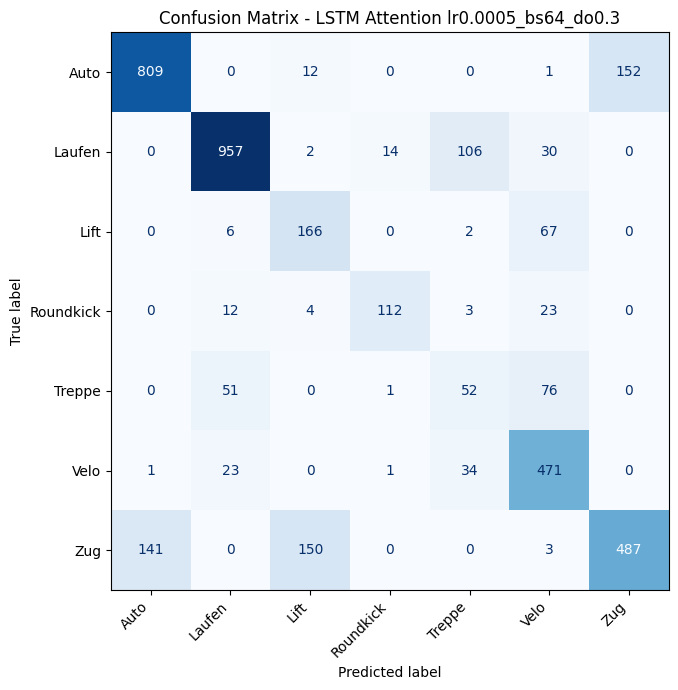

In [34]:
best_model = results[0]["model"]
best_params = {k: results[0][k] for k in lstm_param_grid.keys()}
print("Beste Parameter:", best_params)
print(f"Bestes val/f1: {results[0]['best_val_f1']:.4f}")

# LSTM-Datensatz verwenden, nicht test_ds (das ist für CNN)
test_loader_lstm = DataLoader(test_ds_lstm, batch_size=64, shuffle=False)

plot_confusion_matrix(
    model       = best_model,
    loader      = test_loader_lstm,
    device      = device,
    class_names = le.classes_,
    name        = f"Confusion Matrix - LSTM Attention lr{results[0]['lr']}_bs{results[0]['batch_size']}_do{results[0]['dropout']}",
    save_path   = f"Confusion_Matrix/LSTM_Attention_lr{results[0]['lr']}_bs{results[0]['batch_size']}_do{results[0]['dropout']}.png"
)

## Fazit LSTM

Das LSTM ist bedeutend schlechter für unsere Aufgabe, wie das 1D-CNN, aus diesem Grund wurde nur das 1D-CNN noch weiter optimiert. 

# Kombination LSTM und CNN

Da die Ergebnisse von einem reinen und bidirektionalen LSTM schlechter sind, wie die eines 1D-CNNs wurde noch versucht die beiden in einem Ansatz zu kombinieren. 

In [15]:
class CNNLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),              # 100 → 50
        )
        self.res = ResidualBlock(64, dropout)   # dein bestehender ResidualBlock

        self.down = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
                                          # kein MaxPool → bleibt bei 50
        )
        
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (N, T, C) → (N, C, T)
        x = self.stem(x)
        x = self.res(x)
        x = self.down(x)                 # (N, 128, 50)
        x = x.permute(0, 2, 1)          # (N, 50, 128)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.classifier(last)

In [16]:
cnnlstm_config = {
    "model":       "CNN-LSTM",
    "window_size": 100,
    "step_size":   50,
    "batch_size":  64,
    "lr":          0.0005,
    "epochs":      20,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "dropout":     0.3,
    "hidden_size": 256,
    "num_layers":  2,
}

model_cnnlstm, history_cnnlstm = train(
    config      = cnnlstm_config,
    train_ds    = train_ds_lstm,    # LSTM-Datensatz, permute passiert intern
    test_ds     = test_ds_lstm,
    device      = device,
    project     = "CDL1",
    model_class = CNNLSTMClassifier
)

Training: 100%|██████████| 20/20 [02:31<00:00,  7.60s/epoch, train_f1=0.884, val_f1=0.538, val_acc=0.640]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▃▅▆▆▆▇▇▇▇▇█████████
train/f1,▁▃▅▅▆▆▆▆▇▇▇▇████████
train/loss,█▆▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▁▃▃▅▆▆▁▅▃▃▁█▄▅█▇█▇▆▆
val/f1,▁▃▃▅▆▇▆▇▆▆▆█▇▇███▇▇▆
val/loss,▂▂▁▃▃▂▅▅█▅▆▄▅▆▄▄▄▄▅▅
epoch,20
train/acc,0.92739
train/f1,0.88369


## Fazit

Dieser Ansatz funktioniert bei uns nicht wirklich besser, darum legen wir den Fokus auf die besseren Modelle.